In [1]:
!pip3 install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("Veri okunuyor...")
df = pd.read_csv("../ModifiedDataSets/MovieReviews_Version5.csv")

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    words = [word for word in str(text).split() if word not in stop_words]
    
    pos_tags = pos_tag(words)
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags]
    
    return " ".join(lemmatized_words)

print("Metin ön işleme (Stopwords, Tokenization, Lemmatization) uygulanıyor...")
df["Cleaned_Text"] = df["Reviews"].apply(preprocess_text)

# Boş veya geçersiz satırları temizle
df = df.dropna(subset=['Cleaned_Text', 'emotion'])
df = df[df['Cleaned_Text'].str.strip() != ""]

print(f"Veri ön işleme tamamlandı! Veri boyutu: {df.shape}")
display(df[['Cleaned_Text', 'emotion']].head(3))

Veri okunuyor...
Metin ön işleme (Stopwords, Tokenization, Lemmatization) uygulanıyor...
Veri ön işleme tamamlandı! Veri boyutu: (7223, 5)


,Cleaned_Text,emotion
0,curious note first first movie direct denise d...,joy
1,katherine heigl one guilty pleasures ever sinc...,joy
2,greek gather abstraction love four appropriate...,joy


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X = tfidf.fit_transform(df["Cleaned_Text"])
y = df["emotion"]

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (5778, 10000)
Test seti boyutu: (1445, 10000)


In [20]:
models = {
    "SVM (Linear)": LinearSVC(C=0.5, class_weight='balanced', random_state=42, dual=False),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    "Naive Bayes": MultinomialNB(alpha=0.5),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
}

results = []
best_model_name = ""
best_accuracy = 0
best_predictions = None

for model_name, model in models.items():
    print(f"--- Eğitiliyor: {model_name} ---")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results.append({
        "Model": model_name, 
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    
    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f}\n")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = model_name
        best_predictions = y_pred

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("=== DETAYLI MODEL KARŞILAŞTIRMA SONUÇLARI ===")
print(results_df)

results_df.to_csv("../Results/Version5_Model_Comparison_Results.csv", index=False)
print("\nDetaylı model karşılaştırma sonuçları 'Model_Comparison_Results.csv' olarak kaydedildi.")

--- Eğitiliyor: SVM (Linear) ---
Accuracy: 0.7419 | F1-Score: 0.7416

--- Eğitiliyor: Logistic Regression ---
Accuracy: 0.7170 | F1-Score: 0.7167

--- Eğitiliyor: Naive Bayes ---
Accuracy: 0.7349 | F1-Score: 0.7284

--- Eğitiliyor: Random Forest ---
Accuracy: 0.6547 | F1-Score: 0.6461

=== DETAYLI MODEL KARŞILAŞTIRMA SONUÇLARI ===
                 Model  Accuracy  Precision    Recall  F1-Score
0         SVM (Linear)  0.741869   0.741651  0.741869  0.741571
2          Naive Bayes  0.734948   0.748151  0.734948  0.728360
1  Logistic Regression  0.716955   0.716675  0.716955  0.716663
3        Random Forest  0.654671   0.660611  0.654671  0.646088

Detaylı model karşılaştırma sonuçları 'Model_Comparison_Results.csv' olarak kaydedildi.


In [9]:
!pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Grafik başarıyla çizildi ve kaydedildi: ../Results/Cross_Dataset_Model_Comparison.png


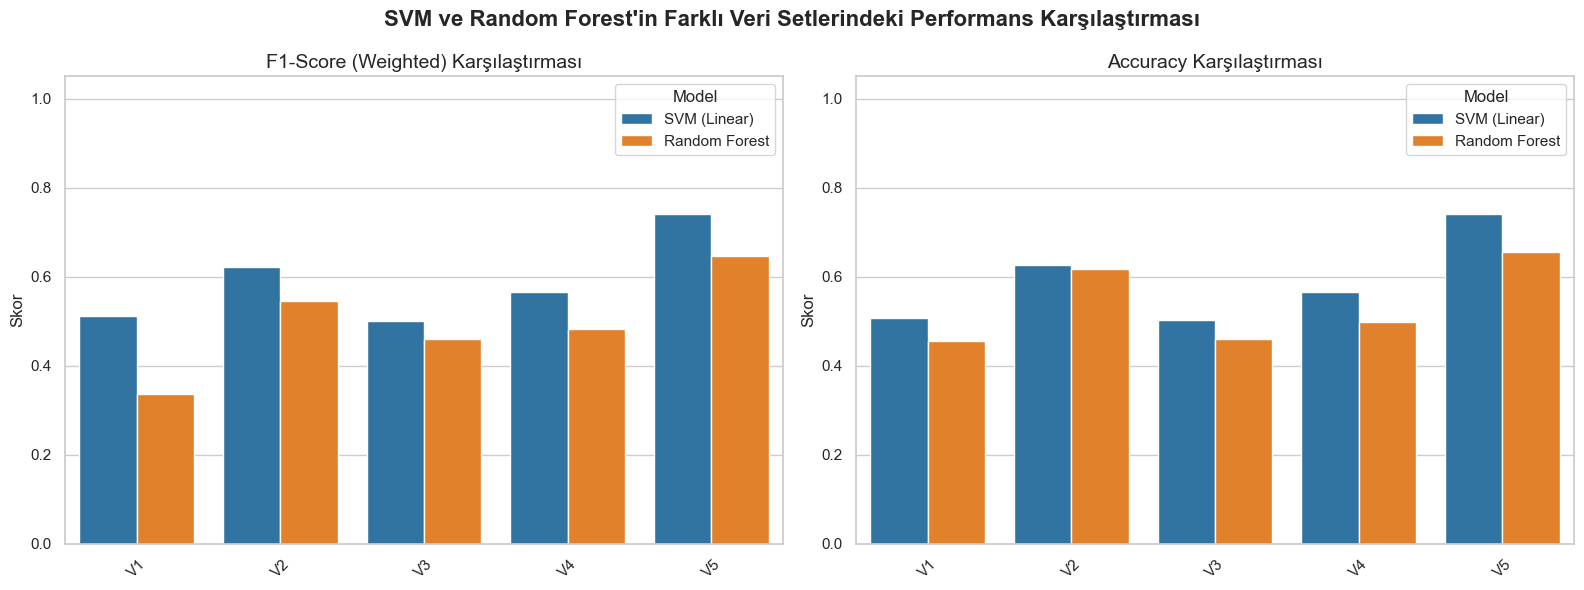

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

csv_files = {
    "V1": "../Results/Model_Comparison_Results-1.csv",
    "V2": "../Results/Oversampled_Model_Comparison_Results.csv",
    "V3": "../Results/Undersampled_Model_Comparison_Results.csv",
    "V4": "../Results/Version4_Model_Comparison_Results.csv",
    "V5": "../Results/Version5_Model_Comparison_Results.csv"
}

all_data = []

for dataset_name, file_path in csv_files.items():
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        
        df_filtered = df[df['Model'].isin(['SVM (Linear)', 'Random Forest'])].copy()
        
        df_filtered['Dataset'] = dataset_name
        all_data.append(df_filtered)
    else:
        print(f"Uyarı: Dosya bulunamadı -> {file_path}")

if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("SVM ve Random Forest'in Farklı Veri Setlerindeki Performans Karşılaştırması", fontsize=16, fontweight='bold')

    sns.barplot(data=combined_df, x='Dataset', y='F1-Score', hue='Model', ax=axes[0], palette=['#1f77b4', '#ff7f0e'])
    axes[0].set_title('F1-Score (Weighted) Karşılaştırması', fontsize=14)
    axes[0].set_ylim(0, 1.05)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Skor')

    sns.barplot(data=combined_df, x='Dataset', y='Accuracy', hue='Model', ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
    axes[1].set_title('Accuracy Karşılaştırması', fontsize=14)
    axes[1].set_ylim(0, 1.05)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Skor')

    plt.tight_layout()
    
    save_path = "../Results/Cross_Dataset_Model_Comparison.png"
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Grafik başarıyla çizildi ve kaydedildi: {save_path}")
    
    plt.show()
else:
    print("Çizilecek veri bulunamadı. Lütfen 'csv_files' içerisindeki dosya yollarını kontrol edin.")